In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from boruta import BorutaPy
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from matplotlib.patches import Patch
from scipy.stats import pointbiserialr
from imblearn.combine import SMOTETomek
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score, f1_score, roc_curve,precision_score, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, 
                             roc_auc_score, recall_score, cohen_kappa_score)
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest, RFE, RFECV, SequentialFeatureSelector, VarianceThreshold, f_classif
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

### Data preparation

In [7]:
df = pd.read_csv('/workspaces/malnutrition/models/models_new/data.csv') 

X = df.drop(columns=['malnutrition'])
y = df['malnutrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print(f"Data size: {df.shape}")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

Data size: (6416, 17)
Training set size: 5872
Test set size: 1284

Class distribution in training set:
malnutrition
0    0.5
1    0.5
Name: proportion, dtype: float64


In [8]:
# Value counts for each column
for col in df.columns:
    print(f"="*20)
    print(df[col].value_counts())

mother education
2.0    2337
1.0    2028
0.0    1571
3.0     480
Name: count, dtype: int64
wealth index
1    1832
2    1317
3    1275
4    1170
5     822
Name: count, dtype: int64
gandaki
0    5705
1     711
Name: count, dtype: int64
koshi
0    5469
1     947
Name: count, dtype: int64
vaccination record
-1    2847
 1    2557
 0    1012
Name: count, dtype: int64
child age
3.0    1478
4.0    1365
1.0    1270
2.0    1259
0.0    1044
Name: count, dtype: int64
health insurance
0.0    6126
1.0     290
Name: count, dtype: int64
residence type
1    3561
0    2855
Name: count, dtype: int64
karnali
0    5673
1     743
Name: count, dtype: int64
meal freqency
-1.0    4117
 0.0     529
 3.0     527
 4.0     411
 2.0     410
 5.0     200
 6.0      97
 1.0      93
 7.0      32
Name: count, dtype: int64
safe stool disposal
-1    2846
 1    2644
 0     926
Name: count, dtype: int64
away privileges
 0    3292
 1    2071
-1    1053
Name: count, dtype: int64
left alone
 0.0    5020
 7.0     526
 2.0     2

In [9]:
# ============================================================================
# STEP 2: Feature Scaling (for distance-based algorithms)
# ============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# STEP 3: Define Models with Initial Parameters
# ============================================================================
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42,
        class_weight='balanced'  # Handle class imbalance
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    'LDA': LinearDiscriminantAnalysis(),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        class_weight='balanced'
    ),
    'SVM': SVC(
        kernel='rbf',
        probability=True,
        random_state=42,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='logloss'
    )
}

# Models that need scaling
needs_scaling = ['Logistic Regression', 'KNN', 'LDA', 'SVM']

# ============================================================================
# STEP 4: Train Models and Collect Results
# ============================================================================
results = []
trained_models = {}

for name, model in models.items():
       
    # Use scaled or unscaled data
    if name in needs_scaling:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
    
    # Train model
    model.fit(X_tr, y_train)
    
    # Predictions
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    average_precision = average_precision_score(y_test, y_pred_proba)
    cohen_kappa = cohen_kappa_score(y_test, y_pred)

    # ROC-AUC (if binary classification)
    if len(np.unique(y)) == 2 and y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    # Cross-validation score
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'CV Mean': cv_mean,
        'CV Std': cv_std,
        'Average Precision': average_precision,
        'Cohen Kappa': cohen_kappa
    })
    
    trained_models[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
# ============================================================================
# STEP 5: Results Summary
# ============================================================================
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n" + "="*40)
print("MODEL COMPARISON RESULTS")
print("="*40)
print(results_df.to_string(index=False))


MODEL COMPARISON RESULTS
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV Mean   CV Std  Average Precision  Cohen Kappa
      Random Forest  0.610592   0.618317 0.610592  0.612546 0.641514 0.626529 0.010921           0.541000     0.217476
                SVM  0.605919   0.614167 0.605919  0.607932 0.644339 0.616826 0.009785           0.541777     0.208803
                LDA  0.604361   0.616674 0.604361  0.606404 0.636981 0.605927 0.012860           0.561052     0.211037
      Decision Tree  0.603583   0.605198 0.603583  0.604286 0.620943 0.601327 0.003216           0.514111     0.193332
Logistic Regression  0.603583   0.615749 0.603583  0.605636 0.637152 0.606268 0.012647           0.561175     0.209306
            XGBoost  0.598131   0.599864 0.598131  0.598881 0.624665 0.629428 0.013276           0.535128     0.182426
                KNN  0.577882   0.580096 0.577882  0.578821 0.597398 0.586175 0.011424           0.493607     0.142018


# DNN

In [ ]:
import random
import numpy as np
import pandas as pd
import keras_tuner as kt
from sklearn.metrics import *
import tensorflow as tf, keras
import matplotlib.pyplot as plt
from keras_tuner import Objective
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
from tensorflow.keras import backend as K
from tensorflow.keras.metrics import Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, f1_score, average_precision_score, 
                             PrecisionRecallDisplay, precision_recall_curve, roc_auc_score, recall_score, cohen_kappa_score)

# To get reproducible
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

set_seed(42)

input_dim = X_train.shape[1]

# 2. Build model function
def build_model(hp):
    model = Sequential()
    model.add(Dense(
        hp.Int('units_1', min_value=32, max_value=256, step=32),
        activation='relu',
        input_dim=input_dim
    ))
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1)))

    model.add(Dense(
        hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.3, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.005, 0.01])),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall()]
    )
    return model

# 3. Set up grid search tuner
grid_tuner = kt.GridSearch(
    build_model,
    objective=Objective("val_recall", direction="max"),
    max_trials=10,  
    overwrite=True,
    directory='ann_tuner_grid',
    project_name='malnutrition_grid'
)

# 4. Run the tuner
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

grid_tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# 5. Evaluate best model
best_ann = grid_tuner.get_best_models(num_models=1)[0]
y_proba_tune = best_ann.predict(X_test).flatten()
y_pred_tune = (y_proba_tune >= 0.5).astype(int)
y_train_pred_tune = (best_ann.predict(X_train).flatten() >= 0.5).astype(int)

# Print evaluation metrics
print("Best Hyperparameters:")
print(grid_tuner.get_best_hyperparameters(1)[0].values)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_tune))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_tune, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tune):.3f}")

Trial 10 Complete [00h 00m 04s]
val_recall: 0.4055793881416321

Best val_recall So Far: 0.471030056476593
Total elapsed time: 00h 01m 14s
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step
Best Hyperparameters:
{'units_1': 32, 'dropout_1': 0.1, 'units_2': 16, 'dropout_2': 0.1, 'learning_rate': 0.001}
------------------------------------------------------
[[730   5]
 [547   2]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.572     0.993     0.726       735
           1      0.286     0.004     0.007       549

    accuracy                          0.570      1284
   macro avg      0.429     0.498     0.366      1284
weighted avg      0.449     0.570     0.418      1284

------------------------------------------------------
Test Avg Precision: 0.483
Test AUC: 0.586
Test Cohen's Kappa: -0.004


### Deep Neural Network for Malnutrition Prediction (F1-Optimized)

TensorFlow version: 2.20.0
GPU Available: []

DATA PREPARATION

Class Distribution:
malnutrition
0    3671
1    2745
Name: count, dtype: int64

Class Proportion:
malnutrition
0    0.572163
1    0.427837
Name: proportion, dtype: float64

Class Weights: {0: 0.8738763279760283, 1: 1.1686703096539162}

Training set: 5132 samples
Test set: 1284 samples

APPLYING SMOTE FOR CLASS BALANCE
After SMOTE: 5872 samples
Class distribution after SMOTE:
malnutrition
0    2936
1    2936
Name: count, dtype: int64

Input dimension: 16

MODEL 1: DEEP NEURAL NETWORK WITH BATCH NORMALIZATION


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,537 (193.50 KB)

 Trainable params: 48,577 (189.75 KB)

...

 Total params: 50,977 (199.13 KB)

 Trainable params: 50,081 (195.63 KB)

 Non-trainable params: 896 (3.50 KB)


TRAINING CONFIGURATION

TRAINING MODEL 1: DEEP NEURAL NETWORK
Epoch 1/200
72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5528 - f1_score: 0.4466 - loss: 0.6316 - precision: 0.4735 - recall: 0.4241
Epoch 1: val_f1_score improved from None to 0.83731, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5380 - f1_score: 0.4583 - loss: 0.6039 - precision: 0.4585 - recall: 0.4581 - val_accuracy: 0.7387 - val_f1_score: 0.8373 - val_loss: 0.4674 - val_precision: 0.8272 - val_recall: 0.8476 - learning_rate: 0.0010
Epoch 2/200
70/74 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5269 - f1_score: 0.4834 - loss: 0.5388 - precision: 0.4525 - recall: 0.5190
Epoch 2: val_f1_score did not improve from 0.83731
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5327 - f1_score: 0.4911 - loss: 0.5299 - precision: 0.4586 - recall: 0.5284 - val_accuracy: 0.6979 - val_f1_score: 0.8016 - val_loss: 0.4550 - val_precision: 0.8366 - val_recall: 0.7693 - learning_rate: 0.0010
Epoch 3/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5353 - f1_score: 0.4942 - loss: 0.5018 - precision: 0.4614 - recall: 0.5323
Epoch 3: val_f1_score did not improve from 0.83731
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/ste

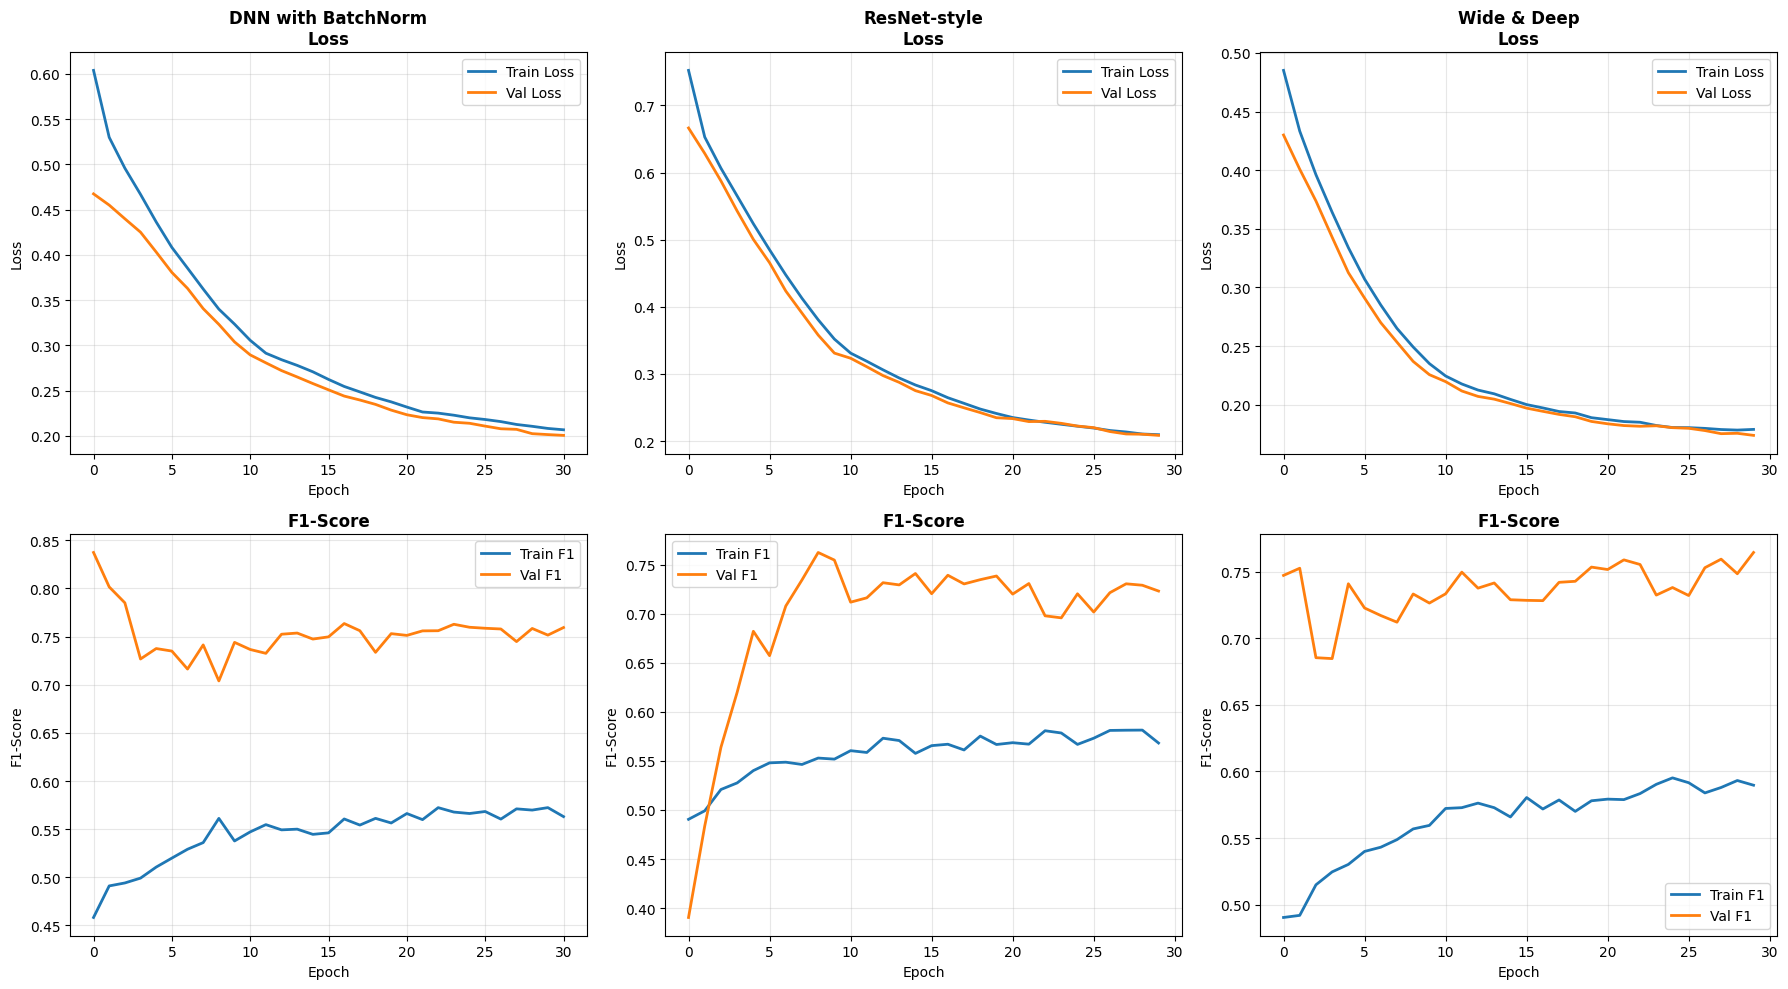

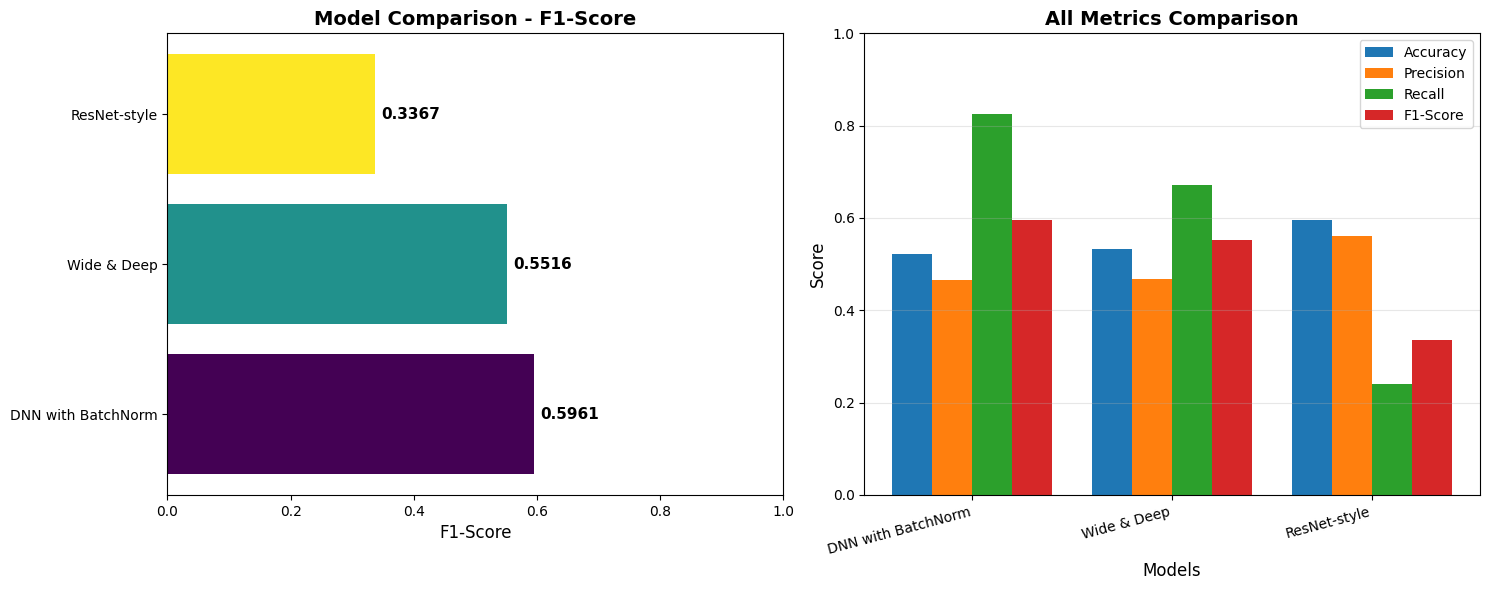

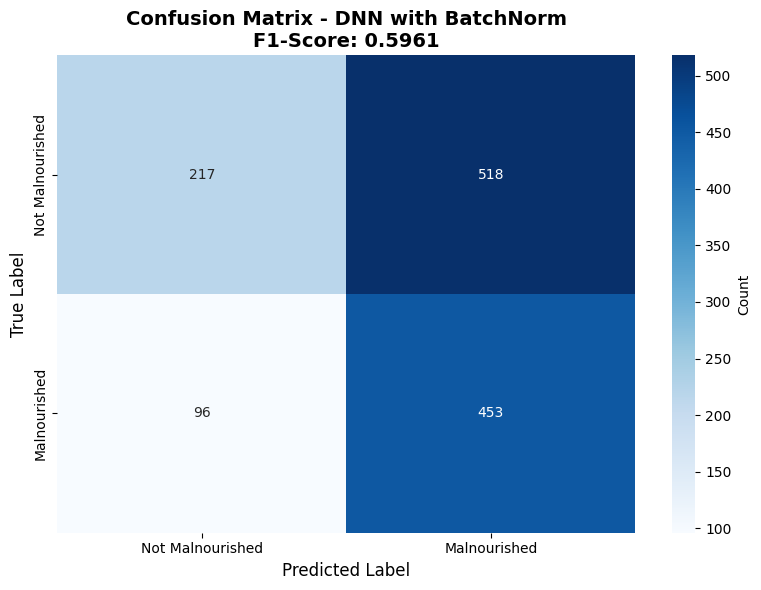

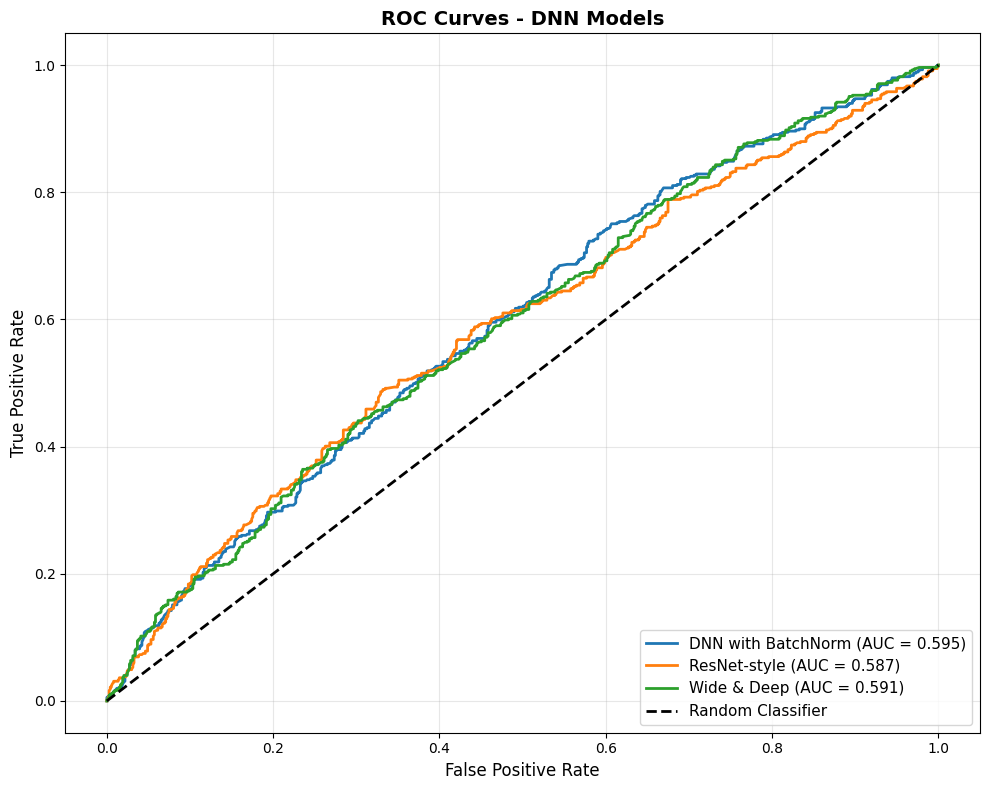


BEST MODEL

Model: DNN with BatchNorm
F1-Score: 0.5961
Accuracy: 0.5218
ROC-AUC: 0.5947



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                            f1_score, accuracy_score, precision_score, 
                            recall_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, 
                                     Input, Concatenate, LeakyReLU)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, 
                                       ModelCheckpoint)

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# ============================================================================
# DATA PREPARATION
# ============================================================================
print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

# Assuming your data is in df with features and target 'malnutrition'
# X = df.drop('malnutrition', axis=1)
# y = df['malnutrition']

# Class distribution
print("\nClass Distribution:")
print(y.value_counts())
print("\nClass Proportion:")
print(y.value_counts(normalize=True))

# Calculate class weights for imbalanced data
class_counts = y.value_counts().sort_index()
total = len(y)
class_weight = {i: total / (len(class_counts) * count) 
                for i, count in enumerate(class_counts)}
print(f"\nClass Weights: {class_weight}")

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# ============================================================================
# FEATURE SCALING
# ============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optional: Apply SMOTE for better balance
print("\n" + "="*80)
print("APPLYING SMOTE FOR CLASS BALANCE")
print("="*80)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE: {len(X_train_balanced)} samples")
print("Class distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

# Convert to numpy arrays
X_train_final = np.array(X_train_balanced, dtype=np.float32)
y_train_final = np.array(y_train_balanced, dtype=np.int32)
X_test_final = np.array(X_test_scaled, dtype=np.float32)
y_test_final = np.array(y_test, dtype=np.int32)

input_dim = X_train_final.shape[1]
print(f"\nInput dimension: {input_dim}")

# ============================================================================
# CUSTOM F1 SCORE METRIC FOR KERAS
# ============================================================================
class F1Score(keras.metrics.Metric):
    """Custom F1 Score metric for binary classification"""
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = keras.metrics.Precision()
        self.recall = keras.metrics.Recall()
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)
    
    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + keras.backend.epsilon()))
    
    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

# ============================================================================
# MODEL 1: DEEP NEURAL NETWORK WITH BATCH NORMALIZATION
# ============================================================================
print("\n" + "="*80)
print("MODEL 1: DEEP NEURAL NETWORK WITH BATCH NORMALIZATION")
print("="*80)

def create_dnn_model_v1(input_dim, learning_rate=0.001):
    """Deep Neural Network with Batch Normalization and Dropout"""
    model = Sequential([
        Input(shape=(input_dim,)),
        
        # First block
        Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        # Second block
        Dense(128, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        # Third block
        Dense(64, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.2),
        
        # Fourth block
        Dense(32, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.2),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_focal_crossentropy',  # Better for imbalanced data
        metrics=['accuracy', 
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 F1Score()]
    )
    
    return model

model_v1 = create_dnn_model_v1(input_dim, learning_rate=0.001)
model_v1.summary()

# ============================================================================
# MODEL 2: RESIDUAL NEURAL NETWORK (ResNet-style)
# ============================================================================
print("\n" + "="*80)
print("MODEL 2: RESIDUAL NEURAL NETWORK")
print("="*80)

def create_residual_block(x, units, dropout_rate=0.3):
    """Create a residual block"""
    # Main path
    fx = Dense(units, kernel_regularizer=regularizers.l2(0.001))(x)
    fx = BatchNormalization()(fx)
    fx = LeakyReLU(alpha=0.1)(fx)
    fx = Dropout(dropout_rate)(fx)
    
    fx = Dense(units, kernel_regularizer=regularizers.l2(0.001))(fx)
    fx = BatchNormalization()(fx)
    
    # Skip connection
    if x.shape[-1] != units:
        x = Dense(units)(x)
    
    # Add skip connection
    fx = layers.Add()([fx, x])
    fx = LeakyReLU(alpha=0.1)(fx)
    
    return fx

def create_resnet_model(input_dim, learning_rate=0.001):
    """ResNet-style architecture for tabular data"""
    inputs = Input(shape=(input_dim,))
    
    # Initial dense layer
    x = Dense(128, kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Dropout(0.3)(x)
    
    # Residual blocks
    x = create_residual_block(x, 128, dropout_rate=0.3)
    x = create_residual_block(x, 64, dropout_rate=0.2)
    x = create_residual_block(x, 32, dropout_rate=0.2)
    
    # Output
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_focal_crossentropy',
        metrics=['accuracy', 
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 F1Score()]
    )
    
    return model

model_v2 = create_resnet_model(input_dim, learning_rate=0.001)
model_v2.summary()

# ============================================================================
# MODEL 3: WIDE & DEEP NETWORK
# ============================================================================
print("\n" + "="*80)
print("MODEL 3: WIDE & DEEP NETWORK")
print("="*80)

def create_wide_deep_model(input_dim, learning_rate=0.001):
    """Wide & Deep architecture"""
    inputs = Input(shape=(input_dim,))
    
    # Wide part (linear)
    wide = Dense(32, activation='relu')(inputs)
    
    # Deep part
    deep = Dense(256, kernel_regularizer=regularizers.l2(0.001))(inputs)
    deep = BatchNormalization()(deep)
    deep = LeakyReLU(alpha=0.1)(deep)
    deep = Dropout(0.3)(deep)
    
    deep = Dense(128, kernel_regularizer=regularizers.l2(0.001))(deep)
    deep = BatchNormalization()(deep)
    deep = LeakyReLU(alpha=0.1)(deep)
    deep = Dropout(0.3)(deep)
    
    deep = Dense(64, kernel_regularizer=regularizers.l2(0.001))(deep)
    deep = BatchNormalization()(deep)
    deep = LeakyReLU(alpha=0.1)(deep)
    deep = Dropout(0.2)(deep)
    
    # Concatenate wide and deep
    combined = Concatenate()([wide, deep])
    
    # Final layers
    x = Dense(32, activation='relu')(combined)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_focal_crossentropy',
        metrics=['accuracy', 
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 F1Score()]
    )
    
    return model

model_v3 = create_wide_deep_model(input_dim, learning_rate=0.001)
model_v3.summary()

# ============================================================================
# TRAINING SETUP
# ============================================================================
print("\n" + "="*80)
print("TRAINING CONFIGURATION")
print("="*80)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_f1_score',
    patience=30,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score',
    factor=0.5,
    patience=10,
    mode='max',
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_f1_score',
    mode='max',
    save_best_only=True,
    verbose=1
)

callbacks_list = [early_stopping, reduce_lr, model_checkpoint]

# ============================================================================
# TRAIN MODEL 1
# ============================================================================
print("\n" + "="*80)
print("TRAINING MODEL 1: DEEP NEURAL NETWORK")
print("="*80)

history_v1 = model_v1.fit(
    X_train_final, y_train_final,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=callbacks_list,
    class_weight=class_weight,
    verbose=1
)

# ============================================================================
# TRAIN MODEL 2
# ============================================================================
print("\n" + "="*80)
print("TRAINING MODEL 2: RESIDUAL NETWORK")
print("="*80)

history_v2 = model_v2.fit(
    X_train_final, y_train_final,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=callbacks_list,
    class_weight=class_weight,
    verbose=1
)

# ============================================================================
# TRAIN MODEL 3
# ============================================================================
print("\n" + "="*80)
print("TRAINING MODEL 3: WIDE & DEEP")
print("="*80)

history_v3 = model_v3.fit(
    X_train_final, y_train_final,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=callbacks_list,
    class_weight=class_weight,
    verbose=1
)

# ============================================================================
# EVALUATION
# ============================================================================
print("\n" + "="*80)
print("MODEL EVALUATION ON TEST SET")
print("="*80)

models = {
    'DNN with BatchNorm': model_v1,
    'ResNet-style': model_v2,
    'Wide & Deep': model_v3
}

results = []

for name, model in models.items():
    print(f"\n{'-'*80}")
    print(f"Evaluating: {name}")
    print('-'*80)
    
    # Predictions
    y_pred_proba = model.predict(X_test_final, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    
    # Metrics
    accuracy = accuracy_score(y_test_final, y_pred)
    precision = precision_score(y_test_final, y_pred, zero_division=0)
    recall = recall_score(y_test_final, y_pred, zero_division=0)
    f1 = f1_score(y_test_final, y_pred)
    roc_auc = roc_auc_score(y_test_final, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test_final, y_pred, 
                                target_names=['Not Malnourished', 'Malnourished']))

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)

print("\n" + "="*80)
print("COMPARISON OF ALL DNN MODELS")
print("="*80)
print(results_df.to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================

# 1. Training History
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

histories = {
    'DNN with BatchNorm': history_v1,
    'ResNet-style': history_v2,
    'Wide & Deep': history_v3
}

for idx, (name, history) in enumerate(histories.items()):
    # Loss
    ax1 = axes[0, idx]
    ax1.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_title(f'{name}\nLoss', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # F1-Score
    ax2 = axes[1, idx]
    ax2.plot(history.history['f1_score'], label='Train F1', linewidth=2)
    ax2.plot(history.history['val_f1_score'], label='Val F1', linewidth=2)
    ax2.set_title(f'F1-Score', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1-Score')
    ax2.legend()
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# F1-Score comparison
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax1.barh(results_df['Model'], results_df['F1-Score'], color=colors)
ax1.set_xlabel('F1-Score', fontsize=12)
ax1.set_title('Model Comparison - F1-Score', fontsize=14, fontweight='bold')
ax1.set_xlim([0, 1])
for bar, f1 in zip(bars, results_df['F1-Score']):
    ax1.text(f1 + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{f1:.4f}', va='center', fontsize=11, fontweight='bold')

# All metrics comparison
ax2 = axes[1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    ax2.bar(x + i*width, results_df[metric], width, label=metric)

ax2.set_xlabel('Models', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax2.legend()
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Confusion Matrix for Best Model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

y_pred_best = (best_model.predict(X_test_final, verbose=0) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test_final, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Malnourished', 'Malnourished'],
            yticklabels=['Not Malnourished', 'Malnourished'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}\nF1-Score: {results_df.iloc[0]["F1-Score"]:.4f}',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# 4. ROC Curves
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_pred_proba = model.predict(X_test_final, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_test_final, y_pred_proba)
    auc = roc_auc_score(y_test_final, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - DNN Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("BEST MODEL")
print("="*80)
print(f"\nModel: {best_model_name}")
print(f"F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")
print(f"Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")
print("\n" + "="*80)

### DNN Hyperparameter Tuning for Maximum F1-Score

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# ============================================================================
# CUSTOM F1 METRIC
# ============================================================================
class F1Score(keras.metrics.Metric):
    """Custom F1 Score metric"""
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = keras.metrics.Precision()
        self.recall = keras.metrics.Recall()
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)
    
    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + keras.backend.epsilon()))
    
    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

# ============================================================================
# HYPERPARAMETER TUNING WITH KERAS TUNER
# ============================================================================
print("="*80)
print("HYPERPARAMETER TUNING FOR DNN - F1 OPTIMIZATION")
print("="*80)

# Prepare data (assuming X_train_final, y_train_final are ready from previous script)
# If not, uncomment and prepare:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# smote = SMOTE(random_state=42)
# X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)

input_dim = X_train_final.shape[1]

def build_tuned_model(hp):
    """
    Build model with hyperparameters to tune
    """
    model = Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # Tune number of layers (3-5)
    n_layers = hp.Int('n_layers', min_value=3, max_value=5, step=1)
    
    for i in range(n_layers):
        # Tune number of units in each layer
        units = hp.Int(f'units_layer_{i}', 
                       min_value=32, 
                       max_value=512, 
                       step=32)
        
        model.add(Dense(units, 
                       kernel_regularizer=regularizers.l2(
                           hp.Float(f'l2_layer_{i}', 
                                   min_value=1e-5, 
                                   max_value=1e-2, 
                                   sampling='log'))))
        
        # Batch normalization
        if hp.Boolean(f'batch_norm_{i}'):
            model.add(BatchNormalization())
        
        # Activation
        activation = hp.Choice(f'activation_{i}', 
                              values=['relu', 'leaky_relu', 'elu'])
        if activation == 'leaky_relu':
            model.add(LeakyReLU(alpha=hp.Float(f'leaky_alpha_{i}', 
                                              min_value=0.01, 
                                              max_value=0.3, 
                                              step=0.05)))
        elif activation == 'elu':
            model.add(layers.ELU())
        else:
            model.add(layers.Activation('relu'))
        
        # Dropout
        dropout_rate = hp.Float(f'dropout_{i}', 
                               min_value=0.1, 
                               max_value=0.5, 
                               step=0.05)
        model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Tune learning rate
    learning_rate = hp.Float('learning_rate', 
                             min_value=1e-5, 
                             max_value=1e-2, 
                             sampling='log')
    
    optimizer = Adam(learning_rate=learning_rate)
    
    # Tune loss function
    loss = hp.Choice('loss', values=['binary_crossentropy', 
                                     'binary_focal_crossentropy'])
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy', 
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 F1Score()]
    )
    
    return model

# ============================================================================
# BAYESIAN OPTIMIZATION TUNER
# ============================================================================
print("\nStarting Bayesian Optimization...")

tuner = kt.BayesianOptimization(
    build_tuned_model,
    objective=kt.Objective('val_f1_score', direction='max'),
    max_trials=50,  # Number of different configurations to try
    executions_per_trial=2,  # Number of times to train each configuration
    directory='keras_tuner_results',
    project_name='malnutrition_dnn_f1_optimization',
    overwrite=True
)

# Callbacks for tuning
early_stopping = EarlyStopping(
    monitor='val_f1_score',
    patience=20,
    mode='max',
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score',
    factor=0.5,
    patience=8,
    mode='max',
    min_lr=1e-7
)

# Calculate class weights
class_counts = pd.Series(y_train_final).value_counts().sort_index()
total = len(y_train_final)
class_weight = {i: total / (len(class_counts) * count) 
                for i, count in enumerate(class_counts)}

print("\nSearching for best hyperparameters...")
print("This may take 30-60 minutes depending on your hardware...")

# Search
tuner.search(
    X_train_final, y_train_final,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight,
    verbose=0
)

# ============================================================================
# RESULTS
# ============================================================================
print("\n" + "="*80)
print("TUNING RESULTS")
print("="*80)

# Get best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters:")
print("-" * 80)
print(f"Number of layers: {best_hps.get('n_layers')}")
for i in range(best_hps.get('n_layers')):
    print(f"  Layer {i+1}:")
    print(f"    Units: {best_hps.get(f'units_layer_{i}')}")
    print(f"    L2 regularization: {best_hps.get(f'l2_layer_{i}'):.6f}")
    print(f"    Batch Normalization: {best_hps.get(f'batch_norm_{i}')}")
    print(f"    Activation: {best_hps.get(f'activation_{i}')}")
    if best_hps.get(f'activation_{i}') == 'leaky_relu':
        print(f"    LeakyReLU alpha: {best_hps.get(f'leaky_alpha_{i}'):.3f}")
    print(f"    Dropout: {best_hps.get(f'dropout_{i}'):.3f}")

print(f"\nLearning rate: {best_hps.get('learning_rate'):.6f}")
print(f"Loss function: {best_hps.get('loss')}")

# Build best model
print("\n" + "="*80)
print("TRAINING BEST MODEL")
print("="*80)

best_model = tuner.hypermodel.build(best_hps)
print("\nBest Model Architecture:")
best_model.summary()

# Train best model with more epochs
history = best_model.fit(
    X_train_final, y_train_final,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_f1_score', patience=30, mode='max', 
                     restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_f1_score', factor=0.5, patience=10, 
                         mode='max', min_lr=1e-7, verbose=1)
    ],
    class_weight=class_weight,
    verbose=1
)

# ============================================================================
# EVALUATION
# ============================================================================
print("\n" + "="*80)
print("EVALUATION ON TEST SET")
print("="*80)

y_pred_proba = best_model.predict(X_test_final, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix)

accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred, zero_division=0)
recall = recall_score(y_test_final, y_pred, zero_division=0)
f1 = f1_score(y_test_final, y_pred)
roc_auc = roc_auc_score(y_test_final, y_pred_proba)

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_final, y_pred, 
                           target_names=['Not Malnourished', 'Malnourished']))

# ============================================================================
# THRESHOLD OPTIMIZATION FOR MAXIMUM F1
# ============================================================================
print("\n" + "="*80)
print("THRESHOLD OPTIMIZATION")
print("="*80)

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba > threshold).astype(int).flatten()
    f1 = f1_score(y_test_final, y_pred_threshold)
    f1_scores.append(f1)

best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"\nOptimal Threshold: {best_threshold:.3f}")
print(f"F1-Score at Optimal Threshold: {best_f1:.4f}")

# Predictions with optimal threshold
y_pred_optimal = (y_pred_proba > best_threshold).astype(int).flatten()

accuracy_opt = accuracy_score(y_test_final, y_pred_optimal)
precision_opt = precision_score(y_test_final, y_pred_optimal, zero_division=0)
recall_opt = recall_score(y_test_final, y_pred_optimal, zero_division=0)

print(f"\nWith Optimal Threshold:")
print(f"  Accuracy:  {accuracy_opt:.4f}")
print(f"  Precision: {precision_opt:.4f}")
print(f"  Recall:    {recall_opt:.4f}")
print(f"  F1-Score:  {best_f1:.4f}")

# ============================================================================
# VISUALIZATION
# ============================================================================

# 1. Training History
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history.history['f1_score'], label='Train F1', linewidth=2)
axes[0, 1].plot(history.history['val_f1_score'], label='Val F1', linewidth=2)
axes[0, 1].set_title('F1-Score', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(history.history['accuracy'], label='Train Acc', linewidth=2)
axes[1, 0].plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1, 0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(thresholds, f1_scores, linewidth=2, color='purple')
axes[1, 1].axvline(best_threshold, color='red', linestyle='--', 
                   label=f'Optimal: {best_threshold:.3f}', linewidth=2)
axes[1, 1].set_title('F1-Score vs Threshold', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Confusion Matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_default = confusion_matrix(y_test_final, y_pred)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Malnourished', 'Malnourished'],
            yticklabels=['Not Malnourished', 'Malnourished'])
axes[0].set_title(f'Confusion Matrix (threshold=0.5)\nF1={f1:.4f}', 
                 fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_optimal = confusion_matrix(y_test_final, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Malnourished', 'Malnourished'],
            yticklabels=['Not Malnourished', 'Malnourished'])
axes[1].set_title(f'Confusion Matrix (threshold={best_threshold:.3f})\nF1={best_f1:.4f}', 
                 fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ============================================================================
# SAVE MODEL
# ============================================================================
print("\n" + "="*80)
print("SAVING BEST MODEL")
print("="*80)

best_model.save('best_dnn_malnutrition_f1_optimized.h5')
print("\nModel saved as: best_dnn_malnutrition_f1_optimized.h5")

# Save optimal threshold
with open('optimal_threshold.txt', 'w') as f:
    f.write(f"{best_threshold:.4f}")
print(f"Optimal threshold saved: {best_threshold:.4f}")

print("\n" + "="*80)
print("HYPERPARAMETER TUNING COMPLETE!")
print("="*80)
print(f"\nFinal F1-Score: {best_f1:.4f}")
print(f"Final Accuracy: {accuracy_opt:.4f}")
print(f"Optimal Threshold: {best_threshold:.3f}")
print("\n" + "="*80)

HYPERPARAMETER TUNING FOR DNN - F1 OPTIMIZATION

Starting Bayesian Optimization...

Searching for best hyperparameters...
This may take 30-60 minutes depending on your hardware...


### DNN Ensemble & Complete ML vs DL Comparison

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix)
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# DL Models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CUSTOM F1 METRIC
# ============================================================================
class F1Score(keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = keras.metrics.Precision()
        self.recall = keras.metrics.Recall()
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)
    
    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + keras.backend.epsilon()))
    
    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

# ============================================================================
# DATA PREPARATION
# ============================================================================
print("="*80)
print("ENSEMBLE DNN & COMPLETE ML vs DL COMPARISON")
print("="*80)

# Assuming X, y are your features and target
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
#                                                      random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Class weights
class_counts = pd.Series(y_train_balanced).value_counts().sort_index()
total = len(y_train_balanced)
class_weight = {i: total / (len(class_counts) * count) 
                for i, count in enumerate(class_counts)}

input_dim = X_train_scaled.shape[1]

# ============================================================================
# CREATE MULTIPLE DNN MODELS FOR ENSEMBLE
# ============================================================================
print("\n" + "="*80)
print("CREATING ENSEMBLE OF 5 DIFFERENT DNNs")
print("="*80)

def create_dnn_variant_1(input_dim):
    """DNN with deep architecture"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.4),
        
        Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Dense(128, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Dense(64, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.2),
        
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_focal_crossentropy',
                 metrics=['accuracy', F1Score()])
    return model

def create_dnn_variant_2(input_dim):
    """DNN with wider architecture"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(384, kernel_regularizer=regularizers.l2(0.0005)),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(0.35),
        
        Dense(256, kernel_regularizer=regularizers.l2(0.0005)),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(0.3),
        
        Dense(128, kernel_regularizer=regularizers.l2(0.0005)),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(0.25),
        
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.0005),
                 loss='binary_crossentropy',
                 metrics=['accuracy', F1Score()])
    return model

def create_dnn_variant_3(input_dim):
    """DNN with ELU activation"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        layers.ELU(),
        Dropout(0.3),
        
        Dense(192, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        layers.ELU(),
        Dropout(0.3),
        
        Dense(96, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        layers.ELU(),
        Dropout(0.2),
        
        Dense(48, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        layers.ELU(),
        Dropout(0.2),
        
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_focal_crossentropy',
                 metrics=['accuracy', F1Score()])
    return model

def create_dnn_variant_4(input_dim):
    """DNN with moderate depth and width"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(320, kernel_regularizer=regularizers.l2(0.0008)),
        BatchNormalization(),
        LeakyReLU(alpha=0.15),
        Dropout(0.35),
        
        Dense(160, kernel_regularizer=regularizers.l2(0.0008)),
        BatchNormalization(),
        LeakyReLU(alpha=0.15),
        Dropout(0.3),
        
        Dense(80, kernel_regularizer=regularizers.l2(0.0008)),
        BatchNormalization(),
        LeakyReLU(alpha=0.15),
        Dropout(0.25),
        
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.0008),
                 loss='binary_crossentropy',
                 metrics=['accuracy', F1Score()])
    return model

def create_dnn_variant_5(input_dim):
    """DNN with SELU activation (self-normalizing)"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='selu', kernel_initializer='lecun_normal'),
        layers.AlphaDropout(0.3),
        
        Dense(192, activation='selu', kernel_initializer='lecun_normal'),
        layers.AlphaDropout(0.3),
        
        Dense(128, activation='selu', kernel_initializer='lecun_normal'),
        layers.AlphaDropout(0.2),
        
        Dense(64, activation='selu', kernel_initializer='lecun_normal'),
        layers.AlphaDropout(0.2),
        
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_focal_crossentropy',
                 metrics=['accuracy', F1Score()])
    return model

# ============================================================================
# TRAIN ENSEMBLE OF DNNs
# ============================================================================
print("\nTraining 5 different DNN architectures...")

dnn_models = []
dnn_predictions = []
dnn_names = ['Deep DNN', 'Wide DNN', 'ELU DNN', 'Moderate DNN', 'SELU DNN']

callbacks_list = [
    EarlyStopping(monitor='val_f1_score', patience=25, mode='max', 
                 restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_f1_score', factor=0.5, patience=10, 
                     mode='max', min_lr=1e-7, verbose=0)
]

X_train_arr = np.array(X_train_balanced, dtype=np.float32)
y_train_arr = np.array(y_train_balanced, dtype=np.int32)
X_test_arr = np.array(X_test_scaled, dtype=np.float32)
y_test_arr = np.array(y_test, dtype=np.int32)

for i, create_model in enumerate([create_dnn_variant_1, create_dnn_variant_2, 
                                   create_dnn_variant_3, create_dnn_variant_4, 
                                   create_dnn_variant_5]):
    print(f"\nTraining {dnn_names[i]}...")
    model = create_model(input_dim)
    
    history = model.fit(
        X_train_arr, y_train_arr,
        validation_split=0.2,
        epochs=150,
        batch_size=64,
        callbacks=callbacks_list,
        class_weight=class_weight,
        verbose=0
    )
    
    dnn_models.append(model)
    
    # Get predictions
    y_pred_proba = model.predict(X_test_arr, verbose=0)
    dnn_predictions.append(y_pred_proba)
    
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    f1 = f1_score(y_test_arr, y_pred)
    acc = accuracy_score(y_test_arr, y_pred)
    
    print(f"  F1-Score: {f1:.4f}, Accuracy: {acc:.4f}")

# ============================================================================
# ENSEMBLE PREDICTIONS
# ============================================================================
print("\n" + "="*80)
print("CREATING DNN ENSEMBLE PREDICTIONS")
print("="*80)

# Average ensemble
dnn_ensemble_avg = np.mean(dnn_predictions, axis=0)
y_pred_ensemble_avg = (dnn_ensemble_avg > 0.5).astype(int).flatten()

# Weighted ensemble (based on validation F1)
# You can adjust weights based on individual model performance
weights = [0.22, 0.18, 0.20, 0.20, 0.20]  # Adjust based on performance
dnn_ensemble_weighted = np.average(dnn_predictions, axis=0, weights=weights)
y_pred_ensemble_weighted = (dnn_ensemble_weighted > 0.5).astype(int).flatten()

# Majority voting
dnn_predictions_binary = [(pred > 0.5).astype(int) for pred in dnn_predictions]
dnn_ensemble_voting = (np.sum(dnn_predictions_binary, axis=0) >= 3).astype(int).flatten()

# Calculate ensemble metrics
f1_avg = f1_score(y_test_arr, y_pred_ensemble_avg)
f1_weighted = f1_score(y_test_arr, y_pred_ensemble_weighted)
f1_voting = f1_score(y_test_arr, y_pred_ensemble_voting)

print(f"\nDNN Ensemble - Average: F1={f1_avg:.4f}")
print(f"DNN Ensemble - Weighted: F1={f1_weighted:.4f}")
print(f"DNN Ensemble - Voting: F1={f1_voting:.4f}")

# ============================================================================
# TRAIN ML MODELS FOR COMPARISON
# ============================================================================
print("\n" + "="*80)
print("TRAINING ML MODELS FOR COMPARISON")
print("="*80)

ml_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=7, learning_rate=0.05,
        num_leaves=31, class_weight='balanced', random_state=42,
        verbose=-1, n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=7, learning_rate=0.05,
        class_weights='Balanced', random_state=42, verbose=0
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=7, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
}

ml_results = []

for name, model in ml_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    ml_results.append({
        'Model': name,
        'Type': 'ML',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"  F1-Score: {f1:.4f}, Accuracy: {accuracy:.4f}")

# ============================================================================
# COLLECT DNN RESULTS
# ============================================================================
dl_results = []

# Individual DNNs
for i, name in enumerate(dnn_names):
    y_pred = (dnn_predictions[i] > 0.5).astype(int).flatten()
    
    accuracy = accuracy_score(y_test_arr, y_pred)
    precision = precision_score(y_test_arr, y_pred, zero_division=0)
    recall = recall_score(y_test_arr, y_pred, zero_division=0)
    f1 = f1_score(y_test_arr, y_pred)
    roc_auc = roc_auc_score(y_test_arr, dnn_predictions[i])
    
    dl_results.append({
        'Model': name,
        'Type': 'DL',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

# DNN Ensembles
for name, y_pred, y_pred_proba in [
    ('DNN Ensemble (Avg)', y_pred_ensemble_avg, dnn_ensemble_avg),
    ('DNN Ensemble (Weighted)', y_pred_ensemble_weighted, dnn_ensemble_weighted),
    ('DNN Ensemble (Voting)', y_pred_ensemble_voting, dnn_ensemble_voting.reshape(-1, 1))
]:
    accuracy = accuracy_score(y_test_arr, y_pred)
    precision = precision_score(y_test_arr, y_pred, zero_division=0)
    recall = recall_score(y_test_arr, y_pred, zero_division=0)
    f1 = f1_score(y_test_arr, y_pred)
    
    if y_pred_proba.ndim > 1:
        roc_auc = None
    else:
        roc_auc = roc_auc_score(y_test_arr, y_pred_proba)
    
    dl_results.append({
        'Model': name,
        'Type': 'DL Ensemble',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE ML vs DL COMPARISON")
print("="*80)

all_results = ml_results + dl_results
results_df = pd.DataFrame(all_results).sort_values('F1-Score', ascending=False)

print("\n")
print(results_df.to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================

# 1. F1-Score Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# F1-Score by model type
ax1 = axes[0, 0]
colors_map = {'ML': 'steelblue', 'DL': 'coral', 'DL Ensemble': 'forestgreen'}
colors = [colors_map[t] for t in results_df['Type']]

bars = ax1.barh(range(len(results_df)), results_df['F1-Score'], color=colors)
ax1.set_yticks(range(len(results_df)))
ax1.set_yticklabels(results_df['Model'])
ax1.set_xlabel('F1-Score', fontsize=12)
ax1.set_title('F1-Score Comparison: ML vs DL', fontsize=14, fontweight='bold')
ax1.set_xlim([0.5, 1.0])

for i, (bar, f1) in enumerate(zip(bars, results_df['F1-Score'])):
    ax1.text(f1 + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{f1:.4f}', va='center', fontsize=9)

# Accuracy comparison
ax2 = axes[0, 1]
bars = ax2.barh(range(len(results_df)), results_df['Accuracy'], color=colors)
ax2.set_yticks(range(len(results_df)))
ax2.set_yticklabels(results_df['Model'])
ax2.set_xlabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_xlim([0.5, 1.0])

# Metrics heatmap
ax3 = axes[1, 0]
metrics_data = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].values
sns.heatmap(metrics_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
            yticklabels=results_df['Model'], ax=ax3, cbar_kws={'label': 'Score'})
ax3.set_title('All Metrics Heatmap', fontsize=14, fontweight='bold')

# Top 5 models
ax4 = axes[1, 1]
top5 = results_df.head(5)
x = np.arange(len(top5))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metrics):
    ax4.bar(x + i*width, top5[metric], width, label=metric)

ax4.set_xlabel('Top 5 Models', fontsize=12)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Top 5 Models - All Metrics', fontsize=14, fontweight='bold')
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(top5['Model'], rotation=20, ha='right', fontsize=9)
ax4.legend()
ax4.set_ylim([0.5, 1.0])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Confusion matrix for best model
print("\n" + "="*80)
print("BEST MODEL ANALYSIS")
print("="*80)

best_model_info = results_df.iloc[0]
print(f"\nBest Model: {best_model_info['Model']}")
print(f"F1-Score: {best_model_info['F1-Score']:.4f}")
print(f"Accuracy: {best_model_info['Accuracy']:.4f}")

# Get predictions for best model
if best_model_info['Model'] == 'DNN Ensemble (Avg)':
    y_pred_best = y_pred_ensemble_avg
elif best_model_info['Model'] == 'DNN Ensemble (Weighted)':
    y_pred_best = y_pred_ensemble_weighted
elif best_model_info['Model'] == 'DNN Ensemble (Voting)':
    y_pred_best = y_pred_ensemble_voting
else:
    # Find the model and get predictions
    pass  # Implement based on your needs

cm = confusion_matrix(y_test_arr, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Malnourished', 'Malnourished'],
            yticklabels=['Not Malnourished', 'Malnourished'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_info["Model"]}\n' + 
          f'F1-Score: {best_model_info["F1-Score"]:.4f}',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)